# Customer Churn Prediction & Segmentation Analysis

This notebook analyzes customer behavior to:
1. **Predict churn risk** - Identify customers at risk of churning (no purchase in 90 days)
2. **Segment customers** - Group customers using K-Means clustering for targeted strategies

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Load Data

In [2]:
# Load dimension tables
dim_customer = pd.read_csv('data/DimCustomer.csv')
dim_channel = pd.read_csv('data/dim_channel.csv')
dim_category = pd.read_csv('data/dim_category.csv')
dim_product = pd.read_csv('data/DimProduct.csv')

# Load fact tables
fact_vente = pd.read_csv('data/FactVentee.csv')
fact_shipping = pd.read_csv('data/FactShipping.csv')
fact_campagne = pd.read_csv('data/FactCampaign.csv')

print("DimCustomer:", dim_customer.shape)
print("FactVentee:", fact_vente.shape)
print("DimChannel:", dim_channel.shape)
print("DimProduct:", dim_product.shape)

# Validate required columns early to fail fast with a clear message
required_columns = {
    'fact_vente': {'FactVentePK', 'dateFK', 'channelFK', 'customerFK', 'productFK', 'price', 'quantity', 'total_ttc'},
    'dim_customer': {'customerPK', 'customer', 'startDate', 'endDate'},
    'dim_channel': {'channelPK', 'channel'}
}

for table_name, required in required_columns.items():
    df_table = locals()[table_name]
    missing = required.difference(df_table.columns)
    if missing:
        raise ValueError(f"Missing columns in {table_name}: {sorted(missing)}")

print("Schema validation passed.")

DimCustomer: (472, 8)
FactVentee: (2342, 16)
DimChannel: (4, 2)
DimProduct: (7441, 7)
Schema validation passed.


In [3]:
dim_customer.head()

,customerPK,customer,customerCode,channelFK,adressFK,startDate,endDate,flag
0,1,Attijari Bank,000121J/P/M000,1,426,2026-03-24 19:48:31.313,NaN,y
1,2,"Attijari Bank , Groupe Alyssa",000121J/P/M000,1,438,2026-03-24 19:48:31.317,NaN,y
2,3,Attijari Bank Groupe Bizerte,000121J/P/M000,1,439,2026-03-24 19:48:31.317,NaN,y
3,4,"Attijari Bank , CA Avenue de Paris",000121J/P/M000,1,440,2026-03-24 19:48:31.317,NaN,y
4,5,Attijari Bank Groupe Cap Bon,000121J/P/M000,1,441,2026-03-24 19:48:31.317,NaN,y


In [4]:
fact_vente.head()

,FactVentePK,dateFK,documentFK,channelFK,customerFK,productFK,price,quantity,remise,total_ht,tva,timbre,total_ttc,startDate,endDate,flag
0,1,20240220,558,4,47,6574,6.0,3,0.0,0.0,0,0,18.0,2026-03-24 22:55:56.616,NaN,y
1,2,20260102,1418,4,48,6575,50.0,1,0.0,0.0,0,0,100.0,2026-03-24 22:55:56.621,NaN,y
2,3,20251230,1418,4,49,6576,90.0,1,0.0,0.0,0,0,90.0,2026-03-24 22:55:56.621,NaN,y
3,4,20251229,1418,4,50,6538,65.0,1,0.0,0.0,0,0,153.0,2026-03-24 22:55:56.621,NaN,y
4,5,20251229,1418,4,50,6539,58.0,2,0.0,0.0,0,0,153.0,2026-03-24 22:55:56.623,NaN,y


## 3. Data Preparation & ETL

In [5]:
# Convert dateFK to datetime (YYYYMMDD format)
original_count = len(fact_vente)
fact_vente = fact_vente[fact_vente['dateFK'] > 0].copy()
dropped_invalid = original_count - len(fact_vente)
if dropped_invalid > 0:
    print(f"Dropped {dropped_invalid} rows with invalid dates (dateFK <= 0)")

fact_vente['dateFK'] = pd.to_datetime(
    fact_vente['dateFK'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

before_nat_drop = len(fact_vente)
fact_vente = fact_vente.dropna(subset=['dateFK']).copy()
dropped_nat = before_nat_drop - len(fact_vente)
if dropped_nat > 0:
    print(f"Dropped {dropped_nat} rows with unparsable dateFK values")

# Get the reference date (latest date in data)
reference_date = fact_vente['dateFK'].max()
print(f"Reference date: {reference_date}")

Dropped 627 rows with invalid dates (dateFK <= 0)
Reference date: 2026-01-02 00:00:00


In [6]:
# Merge sales with customer info (exclude channelFK to avoid conflict with fact_vente's channelFK)
df = fact_vente.merge(
    dim_customer[['customerPK', 'customer', 'startDate', 'endDate']],
    left_on='customerFK',
    right_on='customerPK',
    how='left'
)

# Merge channel info using channelFK from fact_vente (transaction channel)
df = df.merge(
    dim_channel,
    left_on='channelFK',
    right_on='channelPK',
    how='left'
)

print(f"Merged dataset shape: {df.shape}")
df.head()

Merged dataset shape: (1715, 22)


,FactVentePK,dateFK,documentFK,channelFK,customerFK,productFK,price,quantity,remise,total_ht,...,total_ttc,startDate_x,endDate_x,flag,customerPK,customer,startDate_y,endDate_y,channelPK,channel
0,1,2024-02-20,558,4,47,6574,6.0,3,0.0,0.0,...,18.0,2026-03-24 22:55:56.616,NaN,y,47,Makrem AZZ,2026-03-24 19:48:31.814,NaN,4,site web
1,2,2026-01-02,1418,4,48,6575,50.0,1,0.0,0.0,...,100.0,2026-03-24 22:55:56.621,NaN,y,48,haifa ZOU,2026-03-24 19:48:31.814,NaN,4,site web
2,3,2025-12-30,1418,4,49,6576,90.0,1,0.0,0.0,...,90.0,2026-03-24 22:55:56.621,NaN,y,49,Laameri MOU,2026-03-24 19:48:31.814,NaN,4,site web
3,4,2025-12-29,1418,4,50,6538,65.0,1,0.0,0.0,...,153.0,2026-03-24 22:55:56.621,NaN,y,50,Oumayma HKI,2026-03-24 19:48:31.814,NaN,4,site web
4,5,2025-12-29,1418,4,50,6539,58.0,2,0.0,0.0,...,153.0,2026-03-24 22:55:56.623,NaN,y,50,Oumayma HKI,2026-03-24 19:48:31.814,NaN,4,site web


## 4. Feature Engineering

In [7]:
# Convert numeric columns
df['total_ttc'] = pd.to_numeric(df['total_ttc'], errors='coerce').fillna(0)
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0)
df['price'] = pd.to_numeric(df['price'], errors='coerce').fillna(0)

def iqr_outlier_mask(series, multiplier=1.5, non_negative=True):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=series.index)

    lower = q1 - multiplier * iqr
    if non_negative:
        lower = max(0, lower)
    upper = q3 + multiplier * iqr

    return (series < lower) | (series > upper)

# ETL quality step: remove transaction-level outliers before feature engineering
rows_before = len(df)
transaction_outlier_mask = pd.Series(False, index=df.index)
for col in ['total_ttc', 'quantity', 'price']:
    transaction_outlier_mask |= iqr_outlier_mask(df[col], multiplier=1.5, non_negative=True)

df = df.loc[~transaction_outlier_mask].copy()
rows_removed = rows_before - len(df)
print(f"Removed {rows_removed} transaction outliers during ETL")

# Calculate days since last purchase for each transaction
df['days_since_purchase'] = (reference_date - df['dateFK']).dt.days

Removed 160 transaction outliers during ETL


In [8]:
# Aggregate features per customer
customer_features = df.groupby('customerFK').agg({
    'dateFK': [
        ('recency', lambda x: (reference_date - x.max()).days),
        ('first_purchase', 'min'),
        ('last_purchase', 'max')
    ],
    'FactVentePK': 'count',
    'total_ttc': ['sum', 'mean', 'std'],
    'quantity': ['sum', 'mean'],
    'productFK': 'nunique',
    'channelFK': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0],
    'price': 'mean'
}).reset_index()

# Flatten column names
customer_features.columns = [
    'customerFK', 'recency', 'first_purchase', 'last_purchase',
    'frequency', 'monetary_total', 'monetary_mean', 'monetary_std',
    'quantity_total', 'quantity_mean', 'product_diversity',
    'primary_channel', 'avg_price'
]

customer_features['monetary_std'] = customer_features['monetary_std'].fillna(0)

# Remove extreme customer-level outliers from the analytical mart
customers_before = len(customer_features)
customer_outlier_mask = pd.Series(False, index=customer_features.index)
for col in ['frequency', 'monetary_total']:
    customer_outlier_mask |= iqr_outlier_mask(customer_features[col], multiplier=3.0, non_negative=True)

customer_features = customer_features.loc[~customer_outlier_mask].copy()
customers_removed = customers_before - len(customer_features)
print(f"Removed {customers_removed} customer-level outliers")

print(f"Customer features shape: {customer_features.shape}")
customer_features.head()

Removed 4 customer-level outliers
Customer features shape: (393, 13)


,customerFK,recency,first_purchase,last_purchase,frequency,monetary_total,monetary_mean,monetary_std,quantity_total,quantity_mean,product_diversity,primary_channel,avg_price
0,1,612,2024-03-08,2024-04-30,2,0.0,0.0,0.000000,0,0.0,1,1,0.0
1,27,557,2024-05-16,2024-06-24,2,0.0,0.0,0.000000,0,0.0,1,1,0.0
2,33,18,2025-11-26,2025-12-15,2,0.0,0.0,0.000000,0,0.0,1,1,0.0
4,41,42,2025-01-06,2025-11-21,6,672.0,112.0,48.530403,0,0.0,1,1,0.0
5,45,742,2023-12-22,2023-12-22,1,0.0,0.0,0.000000,0,0.0,1,1,0.0


In [9]:
# Calculate customer lifetime
customer_features['customer_lifetime_days'] = (
    customer_features['last_purchase'] - customer_features['first_purchase']
).dt.days

# Purchase velocity (orders per month)
customer_features['purchase_velocity'] = customer_features['frequency'] / (
    customer_features['customer_lifetime_days'] / 30 + 1
)

# Average days between purchases
customer_features['avg_days_between_purchases'] = (
    customer_features['customer_lifetime_days'] / (customer_features['frequency'] - 1 + 1)
)

# Merge channel name
customer_features = customer_features.merge(
    dim_channel,
    left_on='primary_channel',
    right_on='channelPK',
    how='left'
)

customer_features.head()

,customerFK,recency,first_purchase,last_purchase,frequency,monetary_total,monetary_mean,monetary_std,quantity_total,quantity_mean,product_diversity,primary_channel,avg_price,customer_lifetime_days,purchase_velocity,avg_days_between_purchases,channelPK,channel
0,1,612,2024-03-08,2024-04-30,2,0.0,0.0,0.000000,0,0.0,1,1,0.0,53,0.722892,26.500000,1,vente direct
1,27,557,2024-05-16,2024-06-24,2,0.0,0.0,0.000000,0,0.0,1,1,0.0,39,0.869565,19.500000,1,vente direct
2,33,18,2025-11-26,2025-12-15,2,0.0,0.0,0.000000,0,0.0,1,1,0.0,19,1.224490,9.500000,1,vente direct
3,41,42,2025-01-06,2025-11-21,6,672.0,112.0,48.530403,0,0.0,1,1,0.0,319,0.515759,53.166667,1,vente direct
4,45,742,2023-12-22,2023-12-22,1,0.0,0.0,0.000000,0,0.0,1,1,0.0,0,1.000000,0.000000,1,vente direct


In [10]:
# Define churn label: 1 if no purchase in last 90 days, else 0
CHURN_THRESHOLD = 90
customer_features['churn'] = (customer_features['recency'] > CHURN_THRESHOLD).astype(int)

print(f"Churn rate: {customer_features['churn'].mean():.2%}")
print(f"\nChurn distribution:\n{customer_features['churn'].value_counts()}")

Churn rate: 72.01%

Churn distribution:
churn
1    283
0    110
Name: count, dtype: int64


In [11]:
# Create robust RFM scores (1-5 scale)
def make_rfm_score(series, ascending=True):
    ranked = series.rank(method='first', ascending=ascending)
    categories = pd.qcut(ranked, q=5, labels=False, duplicates='drop')
    if categories.isna().all():
        return pd.Series(3, index=series.index, dtype=int)

    # Map whatever bins were created into a 1..5 score range.
    max_bin = int(categories.max()) if pd.notna(categories.max()) else 0
    if max_bin == 0:
        score = pd.Series(3, index=series.index, dtype=int)
    else:
        score = ((categories.astype(float) / max_bin) * 4 + 1).round().astype(int)

    if not ascending:
        score = 6 - score

    return score.clip(1, 5)

customer_features['r_score'] = make_rfm_score(customer_features['recency'], ascending=False)
customer_features['f_score'] = make_rfm_score(customer_features['frequency'], ascending=True)
customer_features['m_score'] = make_rfm_score(customer_features['monetary_total'], ascending=True)

# Combined RFM score
customer_features['rfm_score'] = (
    customer_features['r_score']
    + customer_features['f_score']
    + customer_features['m_score']
)

customer_features[['r_score', 'f_score', 'm_score', 'rfm_score']].head(10)

,r_score,f_score,m_score,rfm_score
0,5,1,1,7
1,5,1,1,7
2,1,1,1,3
3,1,5,5,11
4,5,1,1,7
5,5,1,1,7
6,5,4,1,10
7,1,1,3,5
8,1,1,2,4
9,1,4,5,10


## 5. Exploratory Data Analysis

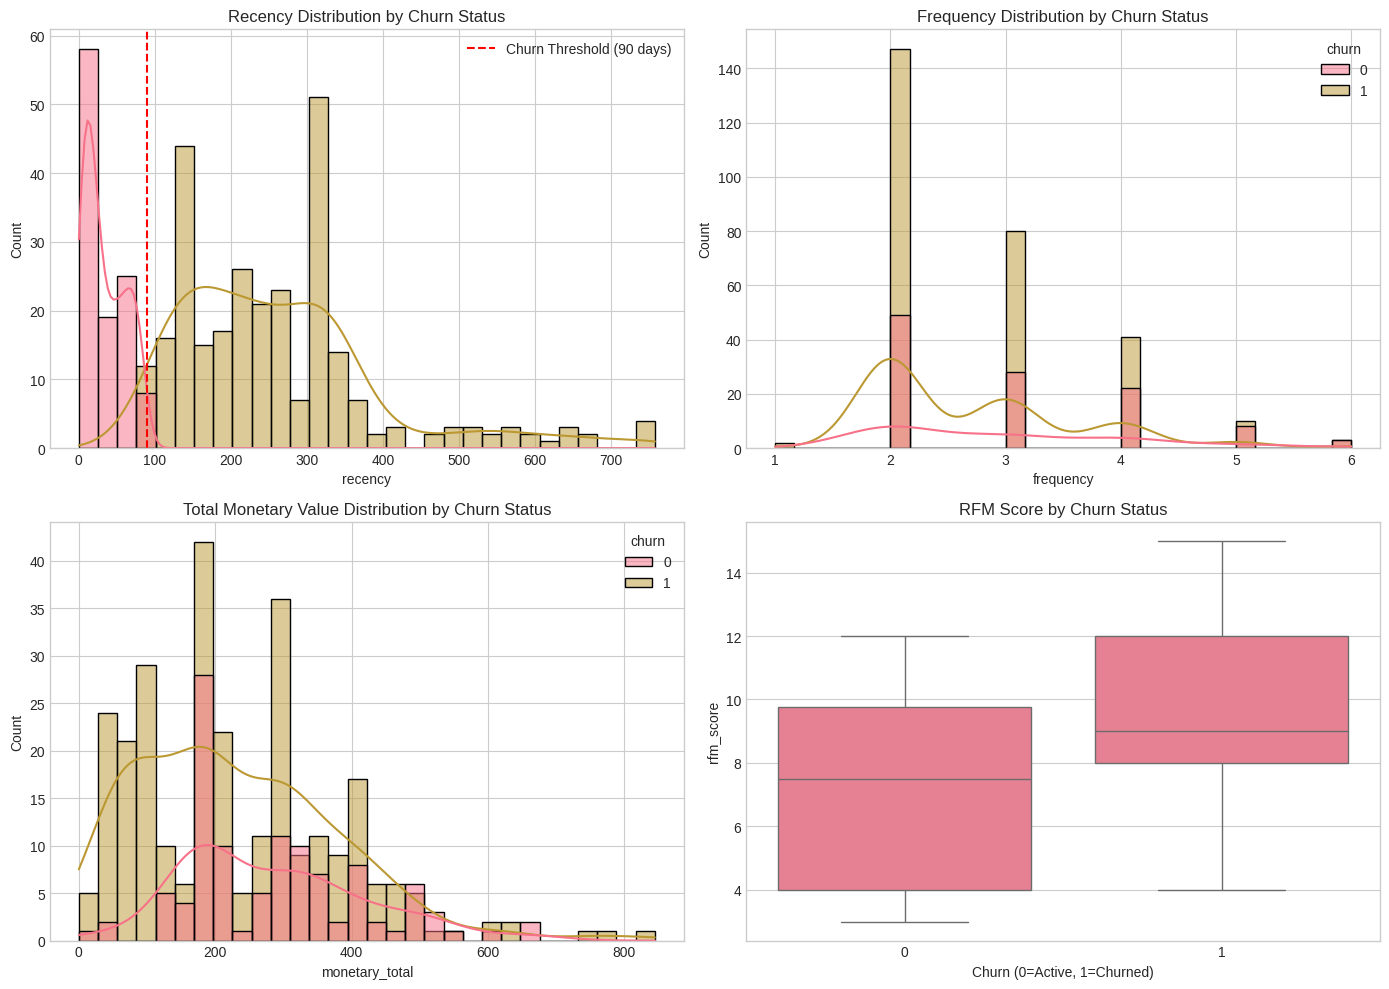

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recency distribution
sns.histplot(data=customer_features, x='recency', hue='churn', bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Recency Distribution by Churn Status')
axes[0, 0].axvline(CHURN_THRESHOLD, color='red', linestyle='--', label=f'Churn Threshold ({CHURN_THRESHOLD} days)')
axes[0, 0].legend()

# Frequency distribution
sns.histplot(data=customer_features, x='frequency', hue='churn', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Frequency Distribution by Churn Status')

# Monetary distribution
sns.histplot(data=customer_features, x='monetary_total', hue='churn', bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Total Monetary Value Distribution by Churn Status')

# RFM Score distribution
sns.boxplot(data=customer_features, x='churn', y='rfm_score', ax=axes[1, 1])
axes[1, 1].set_title('RFM Score by Churn Status')
axes[1, 1].set_xlabel('Churn (0=Active, 1=Churned)')

plt.tight_layout()
plt.show()

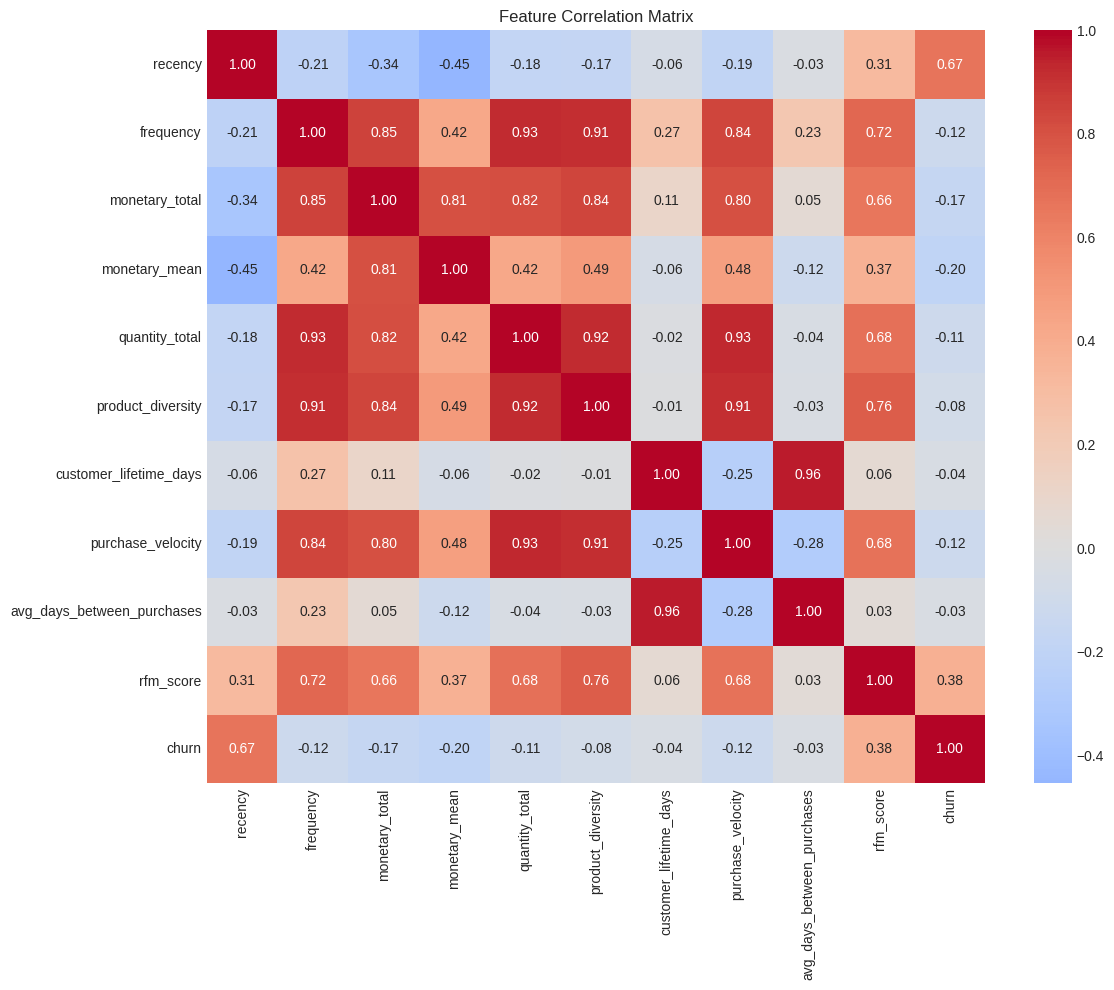

In [13]:
# Correlation heatmap
numeric_cols = ['recency', 'frequency', 'monetary_total', 'monetary_mean', 'quantity_total',
                'product_diversity', 'customer_lifetime_days', 'purchase_velocity',
                'avg_days_between_purchases', 'rfm_score', 'churn']

plt.figure(figsize=(12, 10))
corr_matrix = customer_features[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
# Churn rate by channel
channel_churn = customer_features.groupby('channel').agg(
    total_customers=('customerFK', 'count'),
    churned=('churn', 'sum'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean')
).reset_index()

channel_churn['churn_rate'] = channel_churn['churned'] / channel_churn['total_customers']
channel_churn = channel_churn.sort_values('churn_rate', ascending=False)

print(channel_churn.round(2))

        channel  total_customers  churned  avg_recency  avg_frequency  \
0      site web              387      279       193.99           2.80   
1  vente direct                6        4       451.50           2.33   

   churn_rate  
0        0.72  
1        0.67  


## 6. Churn Prediction Model

In [15]:
# Prepare features for modeling
feature_cols = [
    'recency', 'frequency', 'monetary_total', 'monetary_mean', 'monetary_std',
    'quantity_total', 'quantity_mean', 'product_diversity', 'avg_price',
    'customer_lifetime_days', 'purchase_velocity', 'avg_days_between_purchases',
    'r_score', 'f_score', 'm_score', 'rfm_score'
]

# One-hot encode channel
df_model = customer_features.copy()
df_model = pd.get_dummies(df_model, columns=['channel'], prefix='channel', drop_first=True)

# Update feature columns with encoded channels
feature_cols_final = feature_cols + [col for col in df_model.columns if col.startswith('channel_')]

X = df_model[feature_cols_final]
y = df_model['churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features shape: (393, 17)
Target distribution: {1: 283, 0: 110}


In [16]:
# Train-test split
if X.empty:
    raise ValueError("Feature matrix X is empty. Check upstream feature engineering steps.")

if y.nunique() < 2:
    raise ValueError(
        f"Target has only one class ({y.iloc[0]}). Unable to train churn model. "
        "Adjust churn threshold or inspect data window."
    )

# Stratified split needs at least 2 samples per class in the full dataset
min_class_count = y.value_counts().min()
use_stratify = min_class_count >= 2
if not use_stratify:
    print(
        "Warning: Not enough samples in at least one class for stratified split. "
        "Falling back to non-stratified split."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if use_stratify else None
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (314, 17), Test set: (79, 17)


In [17]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }

    print(f"\n{name}:")
    print(f"ROC-AUC Score: {results[name]['roc_auc']:.4f}")
    print(classification_report(y_test, y_pred))

if not results:
    raise ValueError("No models were successfully trained. Check train/test data and preprocessing.")


Logistic Regression:
ROC-AUC Score: 0.9848
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        22
           1       0.95      1.00      0.97        57

    accuracy                           0.96        79
   macro avg       0.97      0.93      0.95        79
weighted avg       0.96      0.96      0.96        79


Random Forest:
ROC-AUC Score: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        57

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



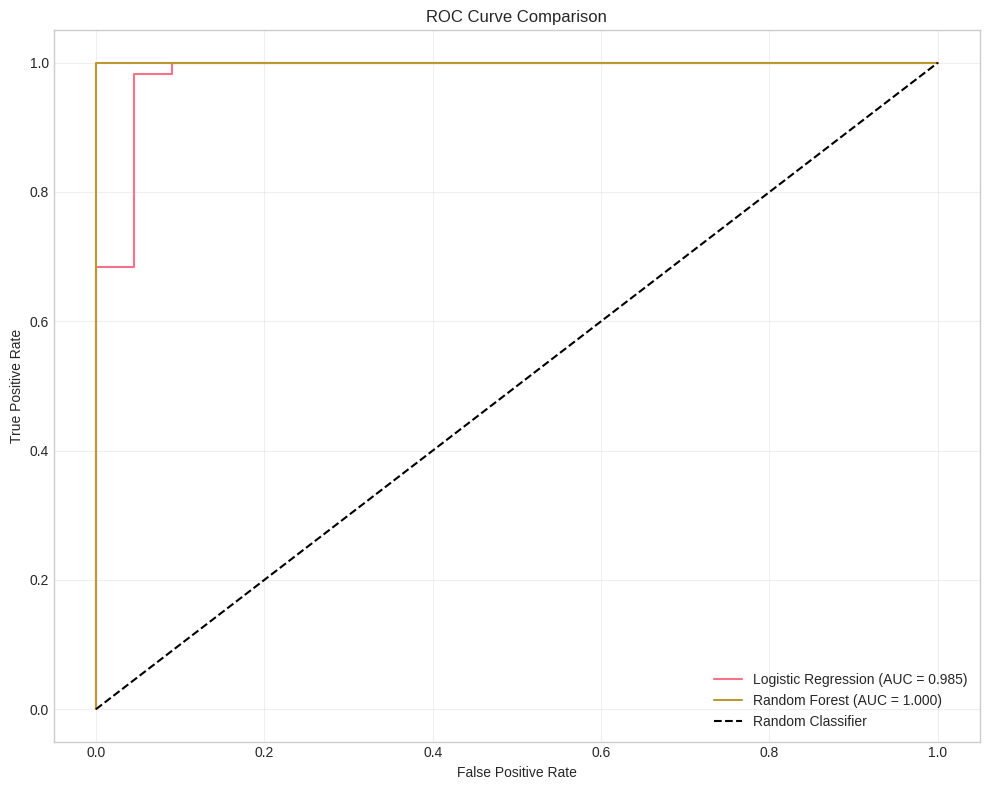

In [18]:
# ROC Curves comparison
plt.figure(figsize=(10, 8))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

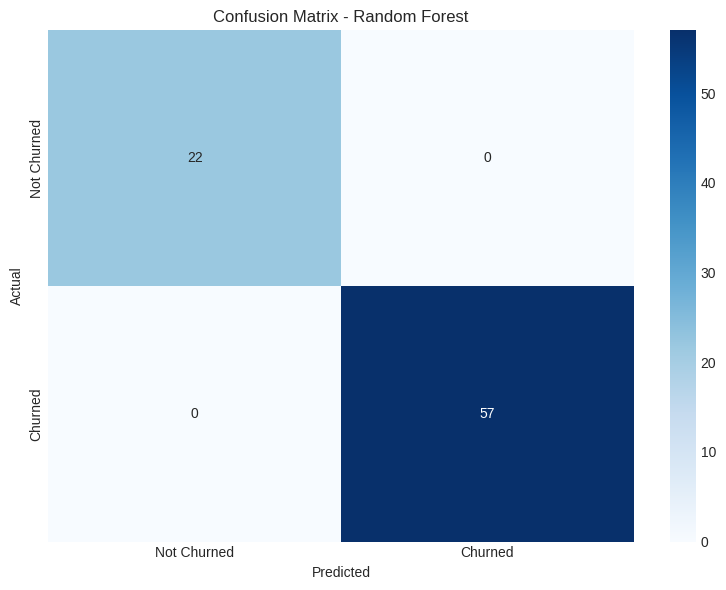

In [19]:
# Confusion Matrix for best model
if not results:
    raise ValueError("Model results are empty. Run model training cell first.")

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_result = results[best_model_name]

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

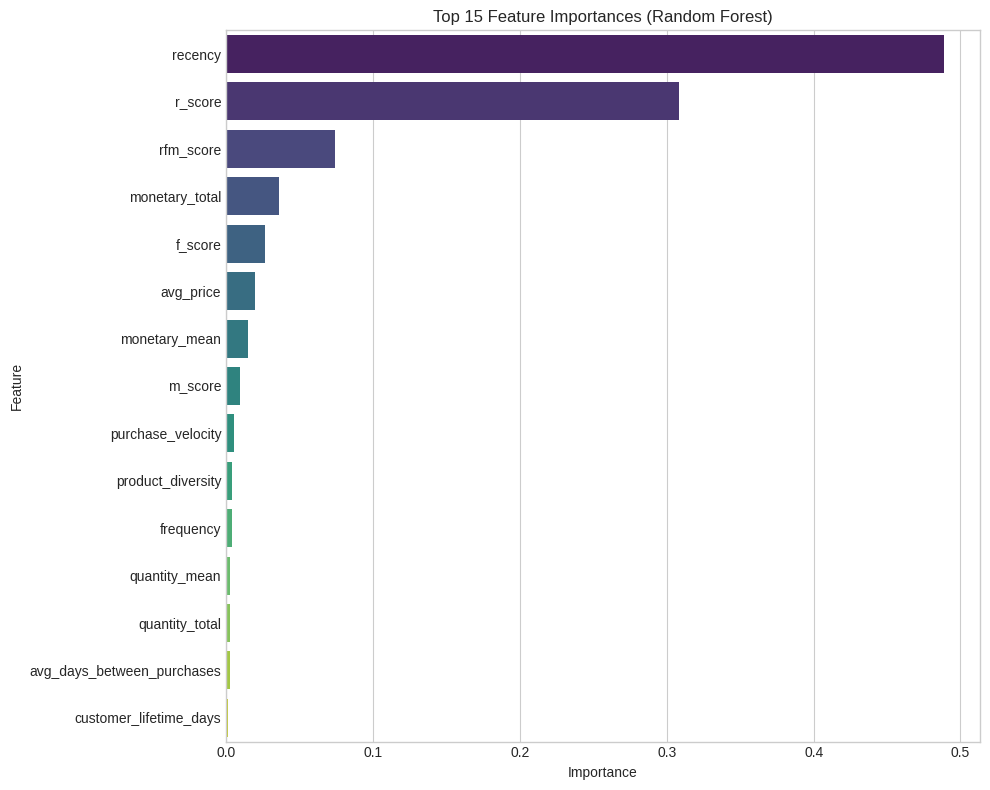

Top 10 Important Features:
              feature  importance
0             recency    0.488839
12            r_score    0.308482
15          rfm_score    0.074323
2      monetary_total    0.035639
13            f_score    0.026409
8           avg_price    0.019945
3       monetary_mean    0.014779
14            m_score    0.009747
10  purchase_velocity    0.005317
7   product_diversity    0.003774


In [20]:
# Feature Importance (Random Forest)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    importance_df = pd.DataFrame({
        'feature': feature_cols_final,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Important Features:")
    print(importance_df.head(10))

In [21]:
# Predict churn probability for all customers
X_all_scaled = scaler.transform(df_model[feature_cols_final])
best_model = best_result['model']
df_model['churn_probability'] = best_model.predict_proba(X_all_scaled)[:, 1]

# Sync probabilities back to customer-level table used in segmentation/exports
if 'churn_probability' in customer_features.columns:
    customer_features = customer_features.drop(columns=['churn_probability'])

customer_features = customer_features.merge(
    df_model[['customerFK', 'churn_probability']],
    on='customerFK',
    how='left'
)

# Show highest risk customers
high_risk = df_model.nlargest(20, 'churn_probability')[
    ['customerFK', 'recency', 'frequency', 'monetary_total', 'churn_probability', 'churn']
].round(2)

print("Top 20 Highest Churn Risk Customers:")
print(high_risk)

Top 20 Highest Churn Risk Customers:
     customerFK  recency  frequency  monetary_total  churn_probability  churn
4            45      742          1             0.0                1.0      1
5            46      738          1             0.0                1.0      1
25           67      758          2            38.0                1.0      1
131         182      107          4           376.0                1.0      1
133         184      114          4           380.0                1.0      1
140         192      123          4           400.0                1.0      1
144         196      124          2           200.0                1.0      1
146         201      129          4           376.0                1.0      1
147         202      129          2           218.0                1.0      1
149         204      130          2           200.0                1.0      1
153         208      133          2           180.0                1.0      1
155         210      134   

## 7. Customer Segmentation with K-Means

In [22]:
# Select features for clustering
cluster_features = ['recency', 'frequency', 'monetary_total', 'product_diversity', 
                    'purchase_velocity', 'rfm_score']

# Scale features for clustering
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(customer_features[cluster_features])

print(f"Clustering features: {cluster_features}")

Clustering features: ['recency', 'frequency', 'monetary_total', 'product_diversity', 'purchase_velocity', 'rfm_score']


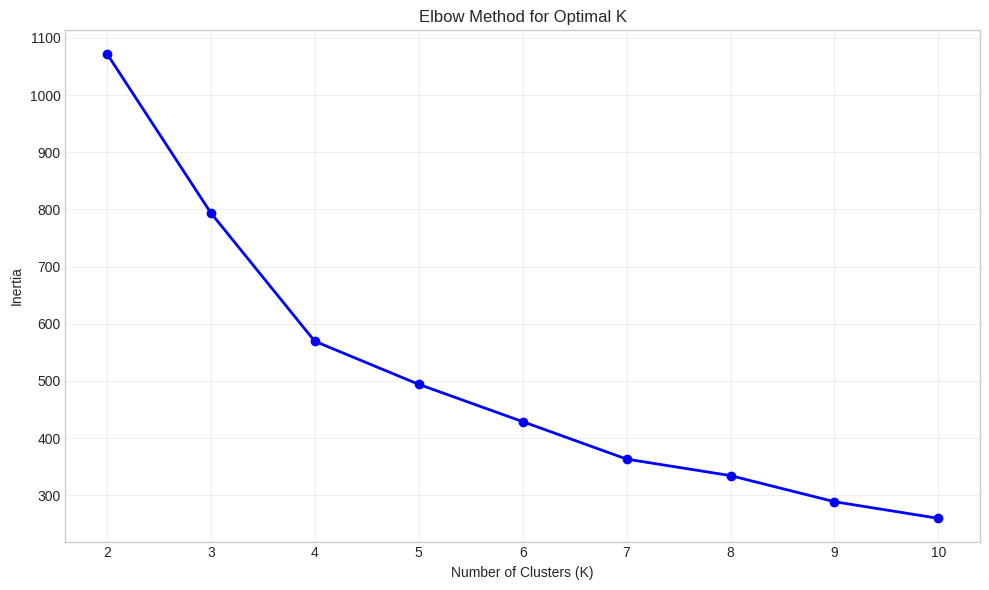

In [23]:
# Elbow method to find optimal K
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Apply K-Means with fixed K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
customer_features['segment'] = kmeans.fit_predict(X_cluster)

print(f"Using K={n_clusters}")
print(f"Segment distribution:\n{customer_features['segment'].value_counts().sort_index()}")

Using K=4
Segment distribution:
segment
0    101
1    116
2     77
3     99
Name: count, dtype: int64


In [26]:
# Profile each segment
segment_profile = customer_features.groupby('segment').agg({
    'customerFK': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary_total': 'mean',
    'product_diversity': 'mean',
    'churn': 'mean',
    'churn_probability': 'mean',
    'rfm_score': 'mean'
}).reset_index()

segment_profile.columns = ['segment', 'n_customers', 'avg_recency', 'avg_frequency', 
                           'avg_monetary', 'avg_product_diversity', 'churn_rate',
                           'avg_churn_prob', 'avg_rfm_score']

segment_profile = segment_profile.sort_values('segment')
print(segment_profile.round(2))

   segment  n_customers  avg_recency  avg_frequency  avg_monetary  \
0        0          101        92.99           2.04        164.32   
1        1          116       179.80           3.09        299.93   
2        2           77       147.35           4.35        453.58   
3        3           99       365.54           1.99        103.14   

   avg_product_diversity  churn_rate  avg_churn_prob  avg_rfm_score  
0                   1.01        0.50            0.51           5.39  
1                   2.95        0.74            0.74          10.34  
2                   4.29        0.61            0.61          12.36  
3                   1.03        1.00            1.00           8.51  


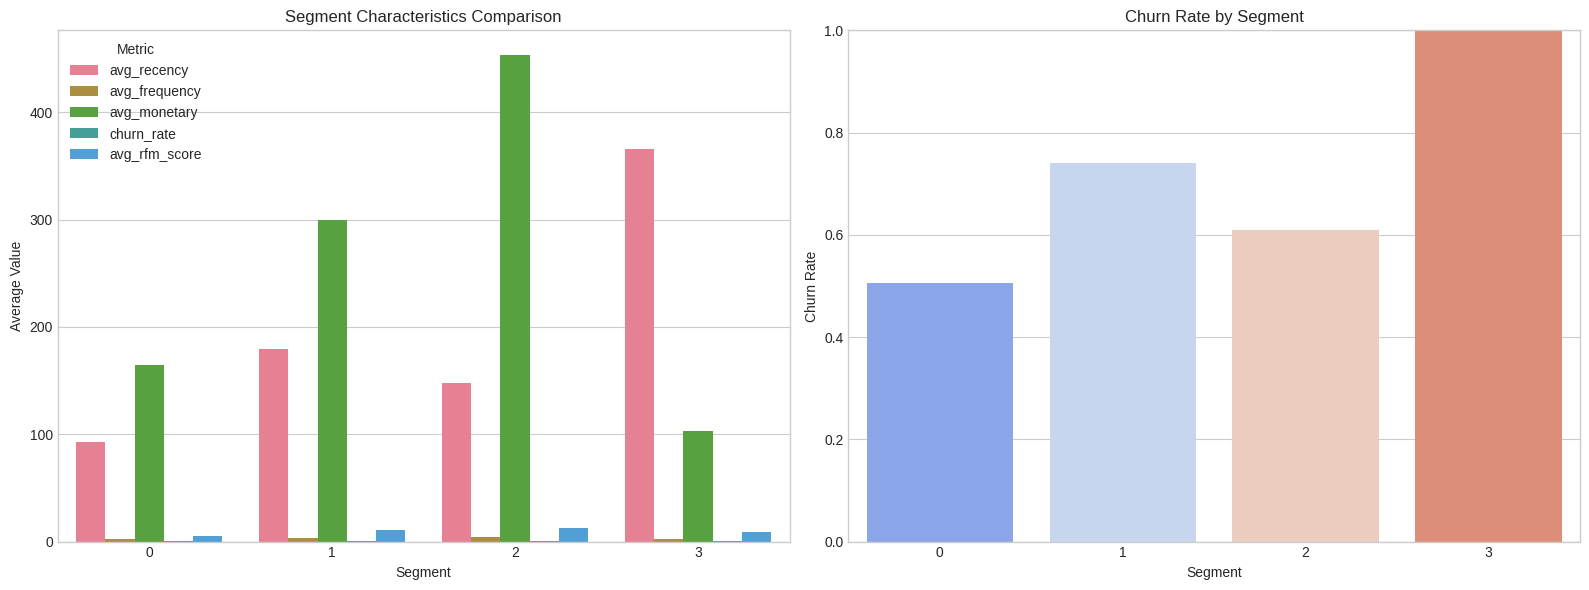

In [27]:
# Segment radar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for segment metrics
metrics = ['avg_recency', 'avg_frequency', 'avg_monetary', 'churn_rate', 'avg_rfm_score']
segment_profile_melted = segment_profile.melt(id_vars='segment', value_vars=metrics,
                                              var_name='metric', value_name='value')
sns.barplot(data=segment_profile_melted, x='segment', y='value', hue='metric', ax=axes[0])
axes[0].set_title('Segment Characteristics Comparison')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Average Value')
axes[0].legend(title='Metric')

# Churn rate by segment
sns.barplot(data=segment_profile, x='segment', y='churn_rate', palette='coolwarm', ax=axes[1])
axes[1].set_title('Churn Rate by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

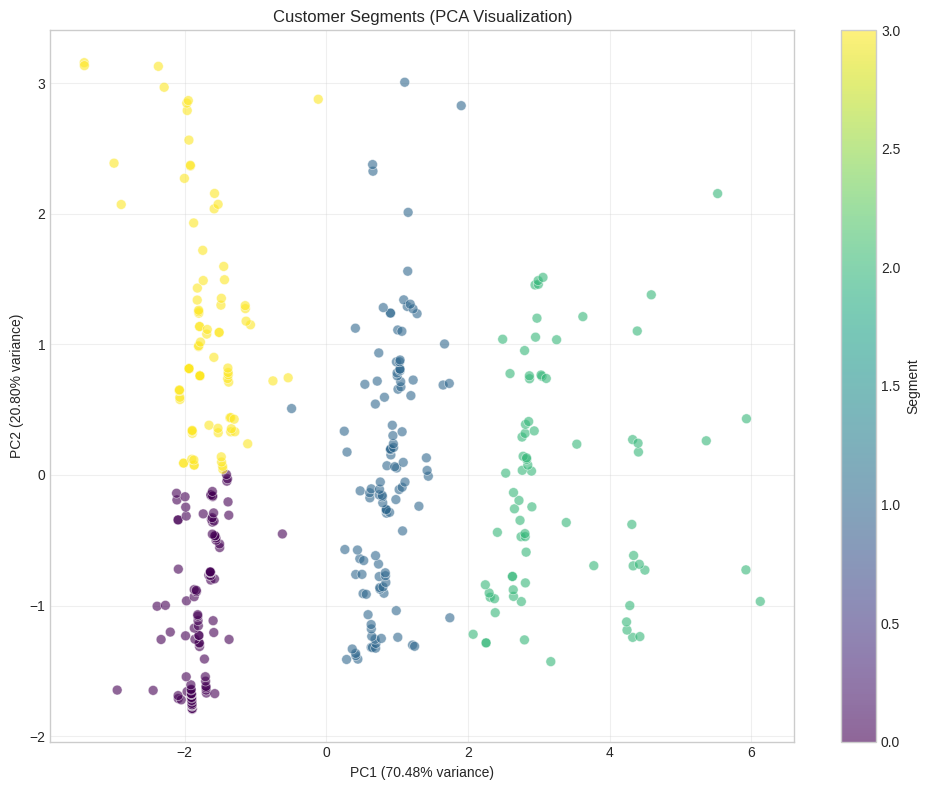

In [28]:
# PCA visualization of clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['segment'], 
                     cmap='viridis', s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Customer Segments (PCA Visualization)')
plt.colorbar(scatter, label='Segment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Assign segment names using robust, data-driven business rules
total_customers = segment_profile['n_customers'].sum()

tiny_segment_threshold = max(2, int(total_customers * 0.01))
recency_q40 = segment_profile['avg_recency'].quantile(0.40)
recency_q50 = segment_profile['avg_recency'].quantile(0.50)
recency_q80 = segment_profile['avg_recency'].quantile(0.80)
churn_q30 = segment_profile['churn_rate'].quantile(0.30)
churn_q70 = segment_profile['churn_rate'].quantile(0.70)
frequency_q30 = segment_profile['avg_frequency'].quantile(0.30)
frequency_q60 = segment_profile['avg_frequency'].quantile(0.60)
frequency_q90 = segment_profile['avg_frequency'].quantile(0.90)
monetary_q80 = segment_profile['avg_monetary'].quantile(0.80)
monetary_q90 = segment_profile['avg_monetary'].quantile(0.90)

def label_segment(row):
    # Very small extreme-value segments are separated into specific outlier archetypes.
    if row['n_customers'] <= tiny_segment_threshold:
        if row['avg_frequency'] >= frequency_q90 and row['churn_rate'] >= churn_q70:
            return 'Whale Accounts At-Risk'
        if row['avg_monetary'] >= monetary_q90:
            return 'High-Value Outliers'

    if row['avg_recency'] >= recency_q80 and row['churn_rate'] >= churn_q70:
        return 'Lost Customers'

    if row['churn_rate'] >= churn_q70 and row['avg_recency'] >= recency_q50:
        return 'At-Risk Declining'

    if row['avg_monetary'] >= monetary_q80 and row['avg_frequency'] >= frequency_q60:
        return 'High-Value Buyers'

    if row['churn_rate'] <= churn_q30 and row['avg_recency'] <= recency_q40:
        return 'Active Loyal'

    if row['avg_frequency'] <= frequency_q30:
        return 'Low Engagement'

    return 'Regular Buyers'

segment_profile['segment_name'] = segment_profile.apply(label_segment, axis=1)
customer_features['segment_name'] = customer_features['segment'].map(
    dict(zip(segment_profile['segment'], segment_profile['segment_name']))
)

print(segment_profile[['segment', 'segment_name', 'n_customers', 'churn_rate']].round(2))

   segment       segment_name  n_customers  churn_rate
0        0       Active Loyal          101        0.50
1        1     Regular Buyers          116        0.74
2        2  High-Value Buyers           77        0.61
3        3     Lost Customers           99        1.00


## 8. Actionable Insights & Recommendations

In [30]:
# High-risk customers by segment
high_risk_by_segment = customer_features[
    customer_features['churn_probability'] > 0.7
].groupby('segment_name').agg(
    count=('customerFK', 'count'),
    avg_recency=('recency', 'mean'),
    avg_monetary=('monetary_total', 'mean')
).reset_index()

print("High-Risk Customers (>70% churn probability) by Segment:")
print(high_risk_by_segment.round(2))

High-Risk Customers (>70% churn probability) by Segment:
        segment_name  count  avg_recency  avg_monetary
0       Active Loyal     51       156.51        160.38
1  High-Value Buyers     47       215.98        461.24
2     Lost Customers     99       365.54        103.14
3     Regular Buyers     86       229.52        292.05


In [31]:
# Summary statistics
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total Customers: {len(customer_features):,}")
print(f"Overall Churn Rate: {customer_features['churn'].mean():.1%}")
print(f"Model ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"Number of Segments: {n_clusters}")
print("\n" + "-" * 60)
print("SEGMENT BREAKDOWN:")
print("-" * 60)
for _, row in segment_profile.iterrows():
    print(f"{row['segment_name']}: {int(row['n_customers'])} customers ({row['n_customers']/len(customer_features)*100:.1f}%), Churn Rate: {row['churn_rate']:.1%}")

ANALYSIS SUMMARY
Total Customers: 393
Overall Churn Rate: 72.0%
Model ROC-AUC: 1.0000
Number of Segments: 4

------------------------------------------------------------
SEGMENT BREAKDOWN:
------------------------------------------------------------
Active Loyal: 101 customers (25.7%), Churn Rate: 50.5%
Regular Buyers: 116 customers (29.5%), Churn Rate: 74.1%
High-Value Buyers: 77 customers (19.6%), Churn Rate: 61.0%
Lost Customers: 99 customers (25.2%), Churn Rate: 100.0%


## 9. Export Results

In [32]:
# Export customer-level predictions and segments
export_df = customer_features[
    ['customerFK', 'recency', 'frequency', 'monetary_total', 'churn', 
     'churn_probability', 'segment', 'segment_name', 'channel']
].copy()

export_df.to_csv('customer_churn_predictions.csv', index=False)
print(f"Exported {len(export_df)} customer records to 'customer_churn_predictions.csv'")

Exported 393 customer records to 'customer_churn_predictions.csv'


In [33]:
# Export high-risk customers for immediate action
high_risk_customers = customer_features[
    customer_features['churn_probability'] >= 0.7
][['customerFK', 'recency', 'frequency', 'monetary_total', 'churn_probability', 'segment_name']].copy()
high_risk_customers = high_risk_customers.sort_values('churn_probability', ascending=False)

high_risk_customers.to_csv('high_risk_customers.csv', index=False)
print(f"Exported {len(high_risk_customers)} high-risk customers to 'high_risk_customers.csv'")

Exported 283 high-risk customers to 'high_risk_customers.csv'
